# XGBoost Classification

This notebook will use the XGBoost classification models, integrated with scikit-learn, to perform win/loss classification on our data. Again, we are comparing the performance on the three different datasets.

## 1. Handling Packages and Data

We begin with all of the imports and data preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import log_loss
from utils import *

In [2]:
df_full = pd.read_csv("../Data/full_data_enc.csv")
df_nodds = pd.read_csv("../Data/nodds_data_enc.csv")
df_odds = pd.read_csv("../Data/odds_data_enc.csv")

In [3]:
df_full_train, df_full_test = chrono_split_df(df_full, threshold=0.8)
df_nodds_train, df_nodds_test = chrono_split_df(df_nodds, threshold=0.8)
df_odds_train, df_odds_test = chrono_split_df(df_odds, threshold=0.8)

In [4]:
X_train_full, y_train = np.array(df_full_train.drop(columns="dj_win")), np.array(
    df_full_train["dj_win"])
X_train_nodds = np.array(df_nodds_train.drop(columns="dj_win"))
X_train_odds = np.array(df_odds_train.drop(columns="dj_win"))

X_test_full, y_test = np.array(df_full_test.drop(columns="dj_win")), np.array(
    df_full_test["dj_win"])
X_test_nodds = np.array(df_nodds_test.drop(columns="dj_win"))
X_test_odds = np.array(df_odds_test.drop(columns="dj_win"))

## 2. Hyperparameter Search

XGBoost has many tunable hyperparameters. We will now develop a pipeline that we can apply to any of our datasets to tune an XGBoost classifier. We already have an expanding window fold-making function in our utils.py file. We will first define a cross-validation loop that will find the average log-loss across the folds for the current parameter combination, as well as the best iteration (number of trees) that achieved the lowest validation log-loss.

In [5]:
def cv_score(params, X, y, n_splits=5):

    """
        Function to calculate the performance of an XGBoost classifier across an expanding window
        fold set. Returns the average loss, standard deviation of losses, and the average number
        of trees for which the ensemble model had the best validation performance.
    """

    losses = [] 
    best_iterations = []

    for train_fold, val_fold in expanding_folds(X.shape[0], n_splits=n_splits):
        model = XGBClassifier(**params, n_estimators=2000, early_stopping_rounds=50, 
                              eval_metric="logloss", tree_method="hist")
        model.fit(X[train_fold], y[train_fold], eval_set=[(X[val_fold], y[val_fold])], verbose=False)
        best_loss = log_loss(y[val_fold], model.predict_proba(X[val_fold])[:, 1])
        losses.append(best_loss)
        best_iterations.append(model.best_iteration + 1)

    return np.mean(losses), np.std(losses), int(np.mean(best_iterations))

Now, we will define a function that will give us a random sample of parameters for a random grid search. Then we will generate the sample of parameters that we will use for our hyperparameter search. It is important that we use the exact same parameters for each of the models, so that the results are comparable, and no model has an unfair advantage by getting lucky with its parameter generations.

In [6]:
def sample_params(rng):

    """
        Returns a sample of parameters for the random grid search.
    """

    params = {
        "learning_rate" : 0.05,
        "max_depth" : rng.integers(2, 6),
        "min_child_weight" : float(np.exp(rng.uniform(np.log(1), np.log(20)))),
        "subsample" : float(rng.uniform(0.6, 1.0)),
        "colsample_bytree": float(rng.uniform(0.5, 1.0)),
        "reg_lambda": float(np.exp(rng.uniform(np.log(0.1), np.log(20)))),
    }

    return params

In [7]:
rng = np.random.default_rng(42)
params_list = [sample_params(rng) for _ in range(40)]

In [8]:
results = []

for name, data in {"Full" : X_train_full, "No Odds" : X_train_nodds, "Odds Only" : X_train_odds}.items():
    for i, params in enumerate(params_list):
        mean_loss, std_losses, best_iteration = cv_score(params, data, y_train)
        results.append({"Data" : name, "Config" : i, **params, "Mean" : mean_loss,
                        "Deviation" : std_losses, "Best_Ensemble_Size" : best_iteration})

results_frame = pd.DataFrame(results)

In [9]:
best_params = results_frame.loc[results_frame.groupby("Data")["Mean"].idxmin()]
best_params

,Data,Config,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,Mean,Deviation,Best_Ensemble_Size
12,Full,12,0.05,3,10.369358,0.783566,0.784371,0.209738,0.347291,0.052648,79
71,No Odds,31,0.05,2,4.296918,0.796283,0.968913,2.068061,0.366018,0.047316,60
86,Odds Only,6,0.05,3,1.587579,0.873220,0.872381,16.837163,0.337244,0.065816,351


As we can see, each dataset-specific model performed best using a different configuration. In particular, the average best ensemble size is much larger for the odds only model than the other two models. This indicates that adding further trees kept decreasing the validation loss in the Odds Only model for much longer than in the other two models. This is because of the lower-dimensional feature space meaning less clear separations are available and so more trees are required for effective feature space partitioning. Now, we will use each of these configurations to train the models on the entire training set.

## 3. Training and Evaluation

We will now train each of the dataset-specific models using the configuration that achieved the lowest average validation loss over the expanding window folds, before evaluating their performance on our test set. We no longer need to use early stopping since this was only required in training to prevent unnecessary iterations when we are no longer improving the validation loss. Now that we have an ideal average iteration depth (number of trees) for each dataset, we just use that as our hyperparameter, and no longer have a variable number of trees depending on the early stopping criterion.

In [10]:
def model_fitter(data_string, X_train, y_train):

    """
        Fits an XGBoost Classifier to the specified dataset using the best parameters found by our
        hyperparameter search.
    """

    best_config = np.array(best_params.loc[best_params["Data"] == data_string]["Config"])

    params = params_list[best_config.squeeze()]

    model = XGBClassifier(**params, n_estimators=np.array(best_params.loc[best_params["Data"] == data_string]
                          ["Best_Ensemble_Size"]).squeeze(), tree_method="hist")
    model.fit(X_train, y_train)

    return model

In [11]:
full_model = model_fitter("Full", X_train_full, y_train)
nodds_model = model_fitter("No Odds", X_train_nodds, y_train)
odds_model = model_fitter("Odds Only", X_train_odds, y_train)

We have now fitted each model with the ideal hyperparameters. Next, we evaluate the performance of each model on the test set, checking the accuracy, log-loss, precision and recall of each model.

In [12]:
def confusion_matrix(y_pred, y):

    """
        Forms the confusion matrix given an array of label predictions (y_pred) and true labels (y).
    """

    aa = np.sum((y_pred == 1) & (y == 1))
    ab = np.sum((y_pred == 1) & (y == 0))
    ba = np.sum((y_pred == 0) & (y == 1))
    bb = np.sum((y_pred == 0) & (y == 0))

    return np.array([[aa, ab], 
                    [ba, bb]])

In [13]:
def performance_analysis(model, X_test, y_test):

    """
        Does a performance analysis on for the specified model on the test set.
    """

    probs = model.predict_proba(X_test)[:, 1]
    y_pred = (probs >= 0.5).astype(float)
    bce = log_loss(y_test, probs)
    acc = np.mean((y_pred == y_test).astype(float))

    mat = confusion_matrix(y_pred, y_test)
    positive_precision = mat[0, 0] / (mat[0, 0] + mat[0, 1]) if (mat[0, 0] + mat[0, 1]) else 0.0
    positive_recall = mat[0, 0] / (mat[0, 0] + mat[1, 0]) if (mat[0, 0] + mat[1, 0]) else 0.0
    negative_precision = mat[1, 1] / (mat[1, 0] + mat[1, 1]) if (mat[1, 0] + mat[1, 1]) else 0.0
    negative_recall = mat[1, 1] / (mat[1, 1] + mat[0, 1]) if (mat[1, 1] + mat[0, 1]) else 0.0

    print("-" * 30)
    print(f"Confusion matrix:")
    print(mat)
    print(f"Positive Precision: {positive_precision :.4f}")
    print(f"Negative Precision: {negative_precision :.4f}")
    print(f"Positive Recall: {positive_recall:.4f}")
    print(f"Negative Recall: {negative_recall:.4f}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Binary Cross-Entropy: {bce:.4f}")

In [14]:
print("Full Dataset Model Evaluation:")
performance_analysis(full_model, X_test_full, y_test)

Full Dataset Model Evaluation:
------------------------------
Confusion matrix:
[[204  33]
 [  4   7]]
Positive Precision: 0.8608
Negative Precision: 0.6364
Positive Recall: 0.9808
Negative Recall: 0.1750
Accuracy: 85.08%
Binary Cross-Entropy: 0.3733


In [15]:
print("No Odds Dataset Model Evaluation:")
performance_analysis(nodds_model, X_test_nodds, y_test)

No Odds Dataset Model Evaluation:
------------------------------
Confusion matrix:
[[205  38]
 [  3   2]]
Positive Precision: 0.8436
Negative Precision: 0.4000
Positive Recall: 0.9856
Negative Recall: 0.0500
Accuracy: 83.47%
Binary Cross-Entropy: 0.4113


In [16]:
print("Odds Only Dataset Model Evaluation:")
performance_analysis(odds_model, X_test_odds, y_test)

Odds Only Dataset Model Evaluation:
------------------------------
Confusion matrix:
[[206  36]
 [  2   4]]
Positive Precision: 0.8512
Negative Precision: 0.6667
Positive Recall: 0.9904
Negative Recall: 0.1000
Accuracy: 84.68%
Binary Cross-Entropy: 0.3656


The performance is similar to what we saw in our other models. The no odds model has the worst performance, achieving an accuracy of $\approx 83.47\%$ and a binary cross-entropy of $0.4113$. The full model and odds only model have interestingly contrasting behaviour. The binary cross-entropy for the odds only model is $0.3656$ compared to a binary cross-entropy of $0.3733$ for the full model. However, the accuracy for the odds only model is $84.68\%$ compared to $85.08\%$ for the full model. The log-loss combines both accuracy and confidence in the predictions. If we have a model that is accurate most of the time, but has a few confidently wrong predictions, then these can blow up the log-loss even in a model with relatively good accuracy. This may be what is happening here. The odds only model actually is on the correct side of $0.5$ less often than the full model, however the full model probably has more incorrect predictions that are further from $0.5$ (overconfident), than the odds model does.

## 4. Model Calibration

First, comparing the probability error residuals of the full model vs the odds only model will help us understand the accuracy and log-loss behaviour we observed.

In [ ]:
def brier_score(model, X_test, y_test):

    """
        Calculates the Brier score for a given model on the test set. Returns the residuals and 
        the mean Brier score.
    """

    probs = model.predict_proba(X_test)[:, 1]
    resids = (y_test - probs) ** 2

    return resids, np.mean(resids)

In [ ]:
resids_full, brier_full = brier_score(full_model, X_test_full, y_test)
resids_odds, brier_odds = brier_score(odds_model, X_test_odds, y_test)
resids_nodds, brier_nodds = brier_score(nodds_model, X_test_nodds, y_test)

In [ ]:
print(f"Brier score of full model: {brier_full:.4f}")
print(f"Brier score of odds model: {brier_odds:.4f}")
print(f"Brier score of no odds model: {brier_nodds:.4f}")

Brier score of full model: 0.1129
Brier score of odds model: 0.1118
Brier score of no odds model: 0.1252


Again, the Brier scores indicate the poor relative performance of the no odds model. The Brier scores for the full model and odds model are quite close, which is in line with the binary cross-entropy results where the full model performed slightly worse. The Brier score penalises confidently wrong predictions, but at a lesser (quadratic) rate than the binary cross-entropy. Still, both the Brier score and binary cross-entropy reflect the hypothesis that the odds model gives probability predictions that are closer to the label for datapoints it is correct on. As mentioned, the accuracy of the full model is better, but the evaluation metrics indicate that the number of correct predictions is outweighed by overconfident incorrect assignments.

To further try and understand this discrepancy, let us now have a look at the calibration plots of the two models. These show pure calibration quality, without being mixed with accuracy.

In [20]:
def calibration_plot(model, X_test, y_test):

    """
        Gives a calibration plot for the specified model and test set.
    """

    probs = model.predict_proba(X_test)[:, 1]
    df = pd.DataFrame({"probs": probs, "y": y_test})
    df_sorted = df.sort_values("probs")

    true_means = []
    true_ses = []
    avg_bin_preds = []

    for split in np.array_split(df_sorted, 8):
        true_mean = np.mean(split[:, 1])
        true_se = np.sqrt(true_mean * (1 - true_mean) / split.shape[0])
        avg_bin_pred = np.mean(split[:, 0])
        true_means.append(true_mean)
        true_ses.append(true_se)
        avg_bin_preds.append(avg_bin_pred)

    fig, ax = plt.subplots(1, figsize=(14, 8))
    ax.errorbar(avg_bin_preds, true_means, yerr=true_ses, fmt="o", capsize=4, label="XGBoost")
    ax.plot(np.linspace(0, 1), np.linspace(0, 1), label="Perfect Calibration")
    ax.set_title(f"Calibration Plot")
    ax.set_xlabel("Average Bin Prediction")
    ax.set_ylabel("True Bin Win Rate")  
    plt.legend()
    plt.show()

Calibration plot for full model:


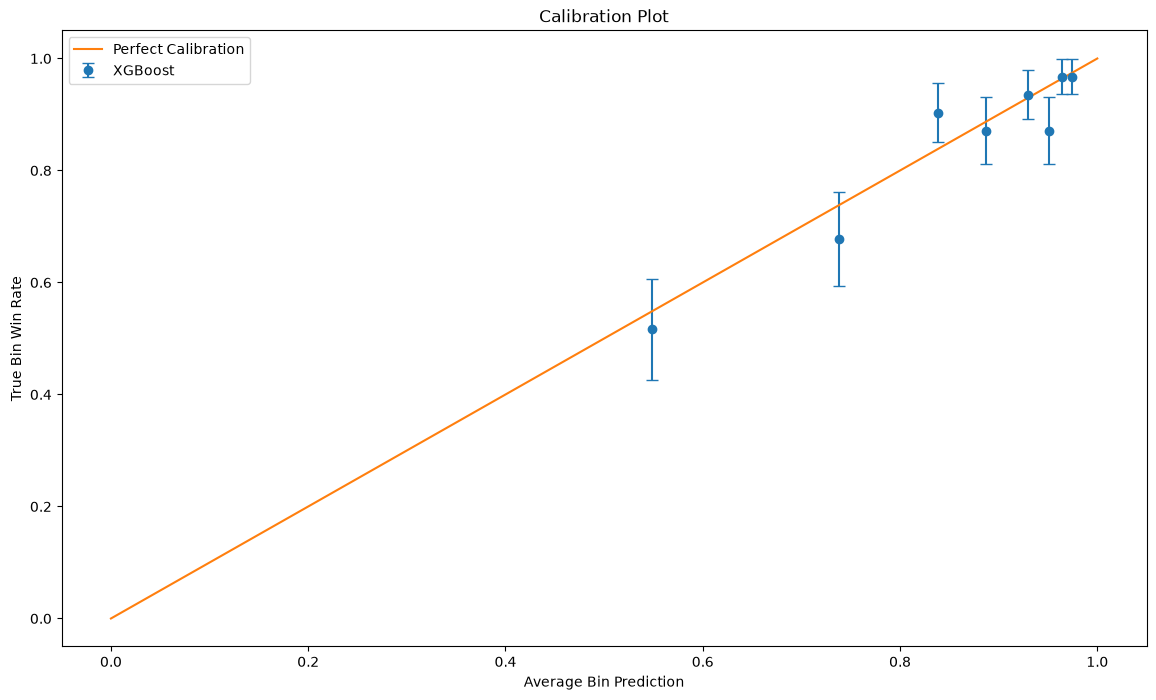

In [21]:
print("Calibration plot for full model:")
calibration_plot(full_model, X_test_full, y_test)

Calibration plot for odds-only model:


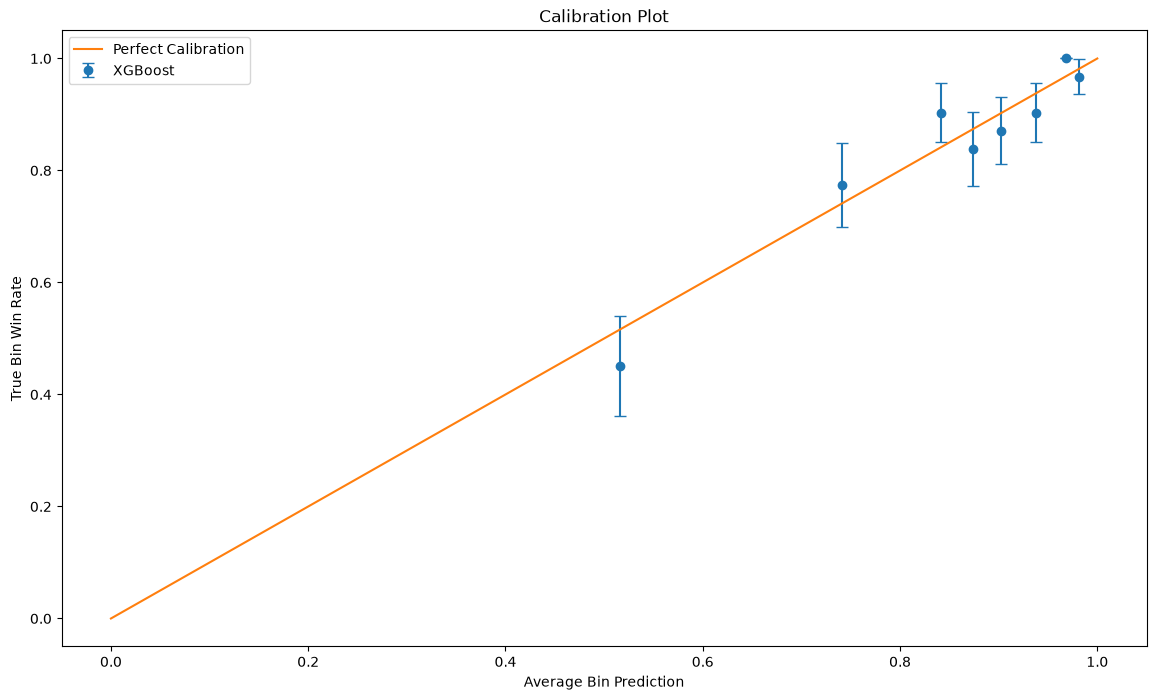

In [22]:
print("Calibration plot for odds-only model:")
calibration_plot(odds_model, X_test_odds, y_test)

The plots show us that the two models are both relatively well calibrated, with most true win rates being close to the perfect calibration line, indicating that the assigned win probability for the class is similar. The error bars are larger nearer to $0.5$ and get smaller as the average bin probabilities get larger. This is expected, because the standard error depends only on $p(1-p)$ because the size of the bins are all equal. $f(p) = p(1-p)$ is a downward parabola that peaks at $0.5$ and equals $0$ at the extreme points of $[0, 1]$.

In comparison with each other, the calibration plots are very similar. In particular, the bins assign a very similar mean prediction probability. The only spot where there is a more noticeable difference is in the first bin, where the odds-only model assigns probabilities closer to $0.5$ than the full model. It could be that similar results are assigned to these bins, and so when they truly are a loss, the binary cross-entropy will punish the full model more due to it assigning higher probabilities to these matches.

## 5. Discussion

**Table 1: Test-set performance (n = 248, 40 losses)**

| Model | Accuracy | Binary Cross-Entropy | Brier Score |
|---|---|---|---|
| Full | **85.08%** | 0.3733 | 0.1129 |
| No Odds | 83.47% | 0.4113 | 0.1252 |
| Odds Only | 84.68% | **0.3656** | **0.1118** |
| Baseline (constant p = 0.839) | 83.87% | 0.4419 | 0.1353 |

**Table 2: Classification breakdown (threshold 0.5)**

| Model | TP | FP | FN | TN | Win Precision | Loss Precision | Win Recall | Loss Recall |
|---|---|---|---|---|---|---|---|---|
| Full | 204 | 33 | 4 | 7 | **0.8608** | 0.6364 | 0.9808 | **0.1750** |
| No Odds | 205 | 38 | 3 | 2 | 0.8436 | 0.4000 | 0.9856 | 0.0500 |
| Odds Only | 206 | 36 | 2 | 4 | 0.8512 | **0.6667** | **0.9904** | 0.1000 |

Positive class = Djokovic win.

In this notebook, we used XGBoost classification models on each of our three datasets. Similar to the previous notebooks, the binary cross-entropy was best for the odds only model ($0.3656$ compared to $0.3733$ for full and $0.4113$ for no odds), indicating better-calibrated, more informative predictions than the models trained on the other datasets. This is usually a combination of less confident (closer to $0.5$) predictions when the model is wrong, and more confident correct predictions. All of the models had a better binary cross-entropy than the baseline model of predicting the overall win rate for every match, indicating that the models are learning to recognise patterns in the data rather than give these simple predictions every time. 

However, loss signal remains difficult for the models to capture. The small amount of false negatives and true negatives for the models indicate that they are rarely predicting a loss, and the loss precision indicates relatively average correctness for loss predictions. The low loss recall across all three models indicates that they are struggling to identify the loss patterns. These are all based off a small number of loss predictions, so the sample size is too small to compare these numbers between models, since the differences may very well be due to chance and a different test set may give different recall values. This is also an artefact of our choice of player. Djokovic rarely loses, so when he does it is mostly an upset, which does not necessarily have a clear separable signal and can often mostly be attributed to random noise. This makes it very difficult for even powerful models such as XGBoost to identify losses correctly.

Finally, our main question for this project is whether adding in our engineered features can improve model performance compared to just using odds data. This notebook, in line with previous notebooks, shows that they do not. The slightly worse log-loss and Brier score for the full model indicate no improvement on the probability predictions in models where we have added in the features. We theorise this is because the odds already contain the information that the extra features provide, since this is publicly available information and is most probably accessible to bookmakers. Hence, adding in these features does not provide any new signal, but adds in more noise, essentially unnecessarily confusing the model.